<a href="https://colab.research.google.com/github/MrGladiator14/notebooks/blob/main/attention_code_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
def softmax(x):
  exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
  return exp_x / exp_x.sum(axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
  d_k = Q.shape[-1]
  # K.T is the transpose of the matrix k
  scores = np.matmul(Q, K.T) / np.sqrt(d_k)
  weights = softmax(scores)
  output = np.matmul(weights, V)
  return output, weights

In [8]:
Q = np.random.rand(3,4)
K = np.random.rand(3,4)
V = np.random.rand(3,4)

output, weights = scaled_dot_product_attention(Q,K,V)
print('attention output :\n' ,output)
print('attention weights :\n' ,weights)


attention output :
 [[0.53465335 0.70561543 0.48869108 0.35025882]
 [0.55331673 0.71146762 0.51385841 0.33654975]
 [0.54100313 0.71014904 0.489973   0.3511989 ]]
attention weights :
 [[0.32978085 0.33196915 0.33825   ]
 [0.38898194 0.30235019 0.30866787]
 [0.33029745 0.32254006 0.3471625 ]]


In [13]:
def multi_head_attention(Q, K, V, num_heads=2):
  d_model = Q.shape[1]
  d_k = d_model // num_heads
  heads_output = []
  for i in range(num_heads):
    Q_h = Q[:, i*d_k:(i+1)*d_k]
    K_h = K[:, i*d_k:(i+1)*d_k]
    V_h = V[:, i*d_k:(i+1)*d_k]

    out, _ = scaled_dot_product_attention(Q_h, K_h, V_h)
    heads_output.append(out)

  heads_output = np.concatenate(heads_output, axis=1)
  return heads_output

output = multi_head_attention(Q,K,V)
print('multi-head attention output :\n' ,output)

multi-head attention output :
 [[0.53834424 0.70645241 0.48357804 0.35292155]
 [0.5503294  0.70843648 0.49777209 0.34644445]
 [0.53777187 0.70809696 0.49130507 0.34985033]]


In [25]:
def dot_product_attention(Q, K, V):
  # d_k = Q.shape[-1] since un scalled
  # K.T is the transpose of the matrix k
  scores = np.matmul(Q, K.T)
  weights = softmax(scores)
  output = np.matmul(weights, V)
  return output, weights

def unscaled_multi_head_attention(Q, K, V, num_heads=2):
  d_model = Q.shape[1]
  d_k = d_model // num_heads
  heads_output = []
  for i in range(num_heads):
    Q_h = Q[:, i*d_k:(i+1)*d_k]
    K_h = K[:, i*d_k:(i+1)*d_k]
    V_h = V[:, i*d_k:(i+1)*d_k]

    out, _ = dot_product_attention(Q_h, K_h, V_h)
    heads_output.append(out)

  heads_output = np.concatenate(heads_output, axis=1)
  return heads_output

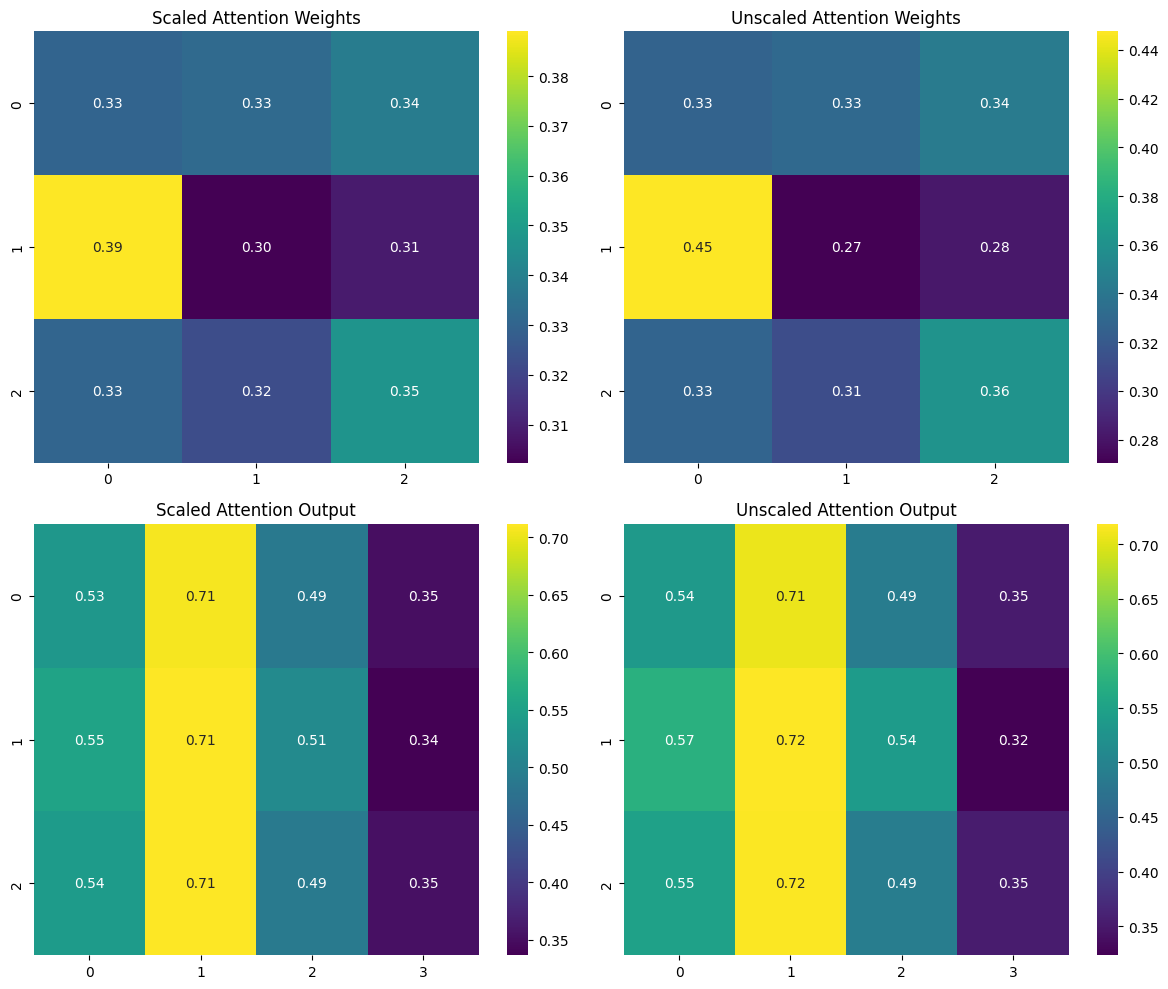

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

scaled_output, scaled_weights = scaled_dot_product_attention(Q,K,V)
unscaled_output, unscaled_weights = dot_product_attention(Q,K,V)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(scaled_weights, annot=True, cmap='viridis', fmt=".2f")
plt.title('Scaled Attention Weights')

plt.subplot(2, 2, 2)
sns.heatmap(unscaled_weights, annot=True, cmap='viridis', fmt=".2f")
plt.title('Unscaled Attention Weights')

plt.subplot(2, 2, 3)
sns.heatmap(scaled_output, annot=True, cmap='viridis', fmt=".2f")
plt.title('Scaled Attention Output')

plt.subplot(2, 2, 4)
sns.heatmap(unscaled_output, annot=True, cmap='viridis', fmt=".2f")
plt.title('Unscaled Attention Output')

plt.tight_layout()
plt.show()

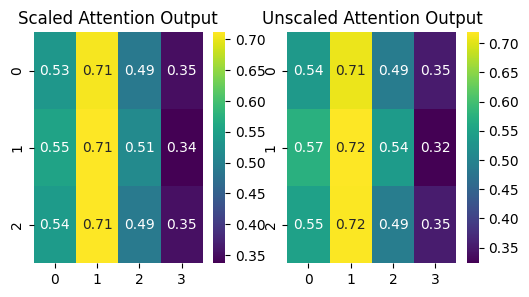

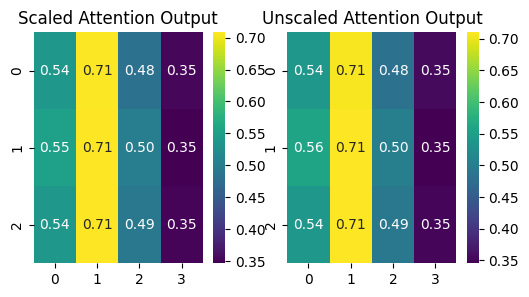

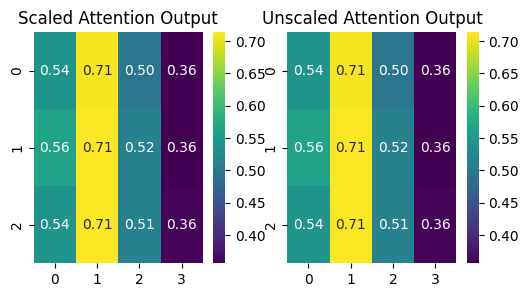

In [29]:
for i in (1, 2, 4):
  output = multi_head_attention(Q,K,V, i)
  unscaled_output = unscaled_multi_head_attention(Q,K,V, i)
  plt.figure(figsize=(6, 3))

  plt.subplot(1, 2, 1)
  sns.heatmap(output, annot=True, cmap='viridis', fmt=".2f")
  plt.title('Scaled Attention Output')

  plt.subplot(1, 2, 2)
  sns.heatmap(unscaled_output, annot=True, cmap='viridis', fmt=".2f")
  plt.title('Unscaled Attention Output')



